In [1]:
from fastai.vision.all import *
from siren import siren_model

In [2]:
# Optional dependency to visualize image gradient
import kornia
import torch

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

laplace_filter = partial(kornia.filters.laplacian, kernel_size=3)
gradient_filter = kornia.filters.sobel

def visualize_filter(image:TensorImage, filter_func):
    filt = filter_func(image.unsqueeze(0))
    # Normalizing to [0, 1] range
    filt -= filt.min()
    filt /= filt.max()
    plt.imshow(filt[0].permute(1, 2, 0).detach().cpu().numpy())
    plt.axis(False)
    plt.show()
    
#Helper function
def decode_prediction(learner, inp):
    y_hat = learn.model(inp.to(device))
    return TensorImage(y_hat.transpose(0, 1).reshape(3, 256, 256))

Using device: mps


# Visualizing the original image

In [3]:
pipe = Pipeline([PILImage.create, ToTensor, IntToFloatTensor, Resize(256)])
image = pipe("Samples/yorkshire_terrier_9.jpg")

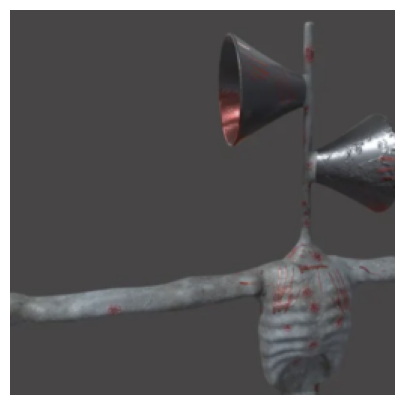

In [32]:
image.show();

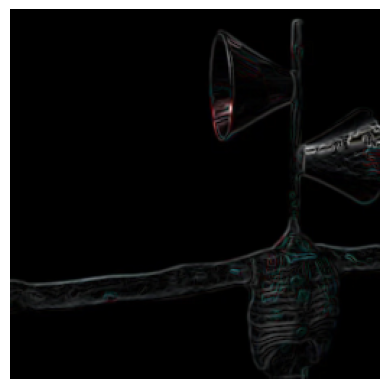

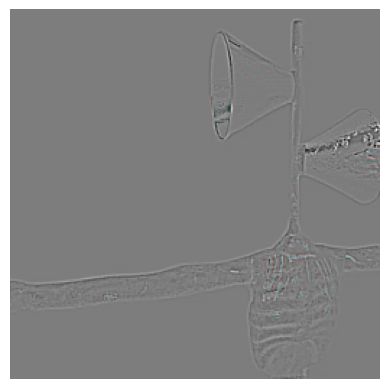

In [33]:
visualize_filter(image, gradient_filter)
visualize_filter(image, laplace_filter)

# Preparing the dataset

The first step is to reshape the image, so that each pixel will be a training example

In [34]:
y = image.reshape(3, -1).transpose(0, 1)
y.shape

torch.Size([65536, 3])

Then we create the coordinates that will be the input. According to the paper, they should be in the range [-1, 1], so we use meshgrid to create the coordinate pair (u, v) easily. In this case, the point (0, 0) represents the center of the image.

In [35]:
g0, g1 = torch.meshgrid(torch.arange(-1, 1, step=2/256), torch.arange(-1, 1, step=2/256), indexing='ij')
x = torch.cat([g0.flatten().unsqueeze(1), g1.flatten().unsqueeze(1)], dim=1)
x = x.float()
x.shape

torch.Size([65536, 2])

Performing a quick check to make sure that the coordinates are correct

In [36]:
for coord, pixel_value in zip(x, y):
    c = ( 128 * (1 + coord)).long()
    assert (image[:, c[0], c[1]] == pixel_value).all(), "Pixel values do not match"

Now creating the dataset (image coordinates) -> (image pixel)

In [37]:
from torch.utils.data import TensorDataset, random_split
dset = TensorDataset(x.to(device), y.to(device))

Random splitting the pixels so 20% of them are used for validation

In [38]:
val_pct = 0.2
val_len = int(len(dset)*val_pct)
lengths = [len(dset)-val_len, val_len]
train_dset, val_dset = random_split(dset, lengths)

In [39]:
dls = DataLoaders(DataLoader(train_dset, bs=256), DataLoader(val_dset, bs=4096))

# Creating the model, optimizer and loss

In [40]:
learn = Learner(dls, 
    siren_model([2, 256, 128, 64, 32, 3]).to(device), 
    loss_func=MSELossFlat(),
    opt_func=ranger
    )

In [41]:
learn.model

Sequential(
  (0): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): Siren(w0=30.0)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Siren(w0=1.0)
  )
  (2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Siren(w0=1.0)
  )
  (3): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Siren(w0=1.0)
  )
  (4): Sequential(
    (0): Linear(in_features=32, out_features=3, bias=True)
    (1): Siren(w0=1.0)
  )
)

# Starting the training

In [42]:
learn.fit_flat_cos(5, lr=1e-3)

epoch,train_loss,valid_loss,time
0,0.027928,0.008301,00:01
1,0.003332,0.002263,00:01
2,0.001690,0.001581,00:01
3,0.001206,0.001294,00:01
4,0.000665,0.000652,00:01


This is the result after 5 epochs of training. You can already see the underlying image.

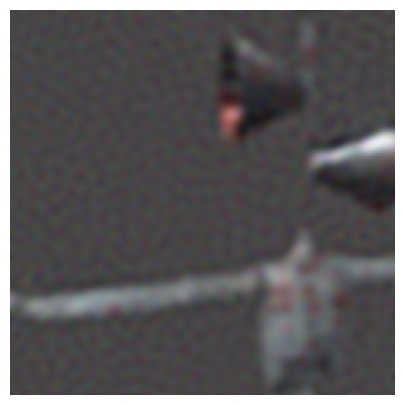

In [43]:
decode_prediction(learn, x).show();

Now the long training, so it captures the details

In [44]:
learn.fit_flat_cos(300, lr=1e-3)

epoch,train_loss,valid_loss,time
0,0.001001,0.000733,00:01
1,0.000869,0.000723,00:01
2,0.000777,0.000732,00:01
3,0.000715,0.000752,00:01
4,0.000662,0.000741,00:01
5,0.000632,0.000716,00:01
6,0.000603,0.000521,00:01
7,0.000566,0.000520,00:01
8,0.000525,0.000530,00:01
9,0.000499,0.000537,00:01


Visualizing the results of the training

<Axes: title={'center': 'decoded'}>

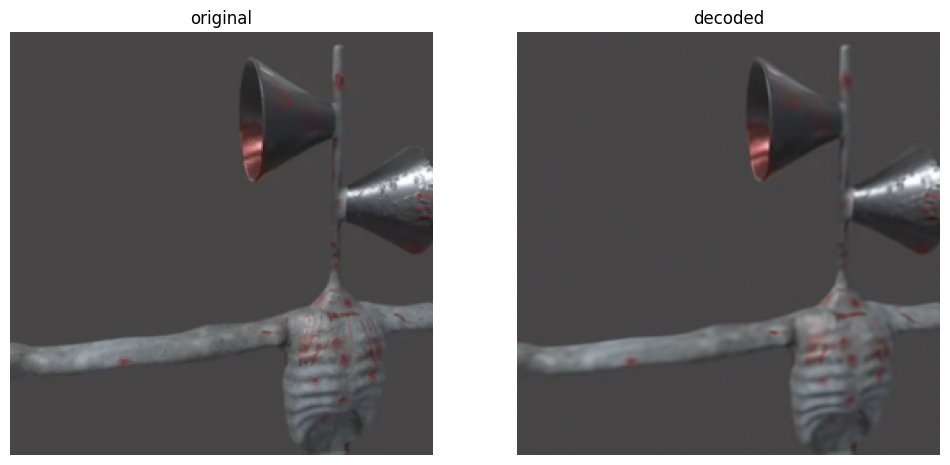

In [45]:
decoded = decode_prediction(learn, x)
_, ax = subplots(1, 2, figsize=(12, 20))
image.show(ax[0], title='original')
decoded.show(ax[1], title='decoded')

Visualizing the gradient and laplacian in the original image

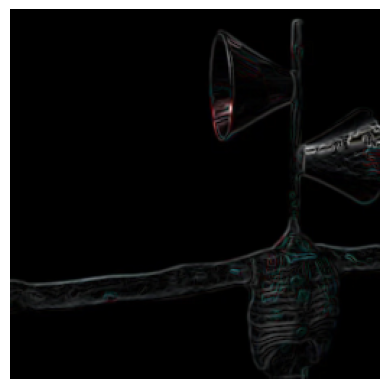

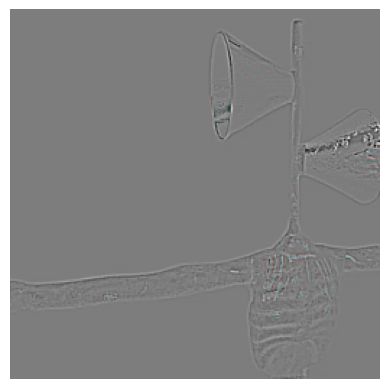

In [46]:
visualize_filter(image, gradient_filter)
visualize_filter(image, laplace_filter)

Visualizing the gradient and laplacian in the image created by the network

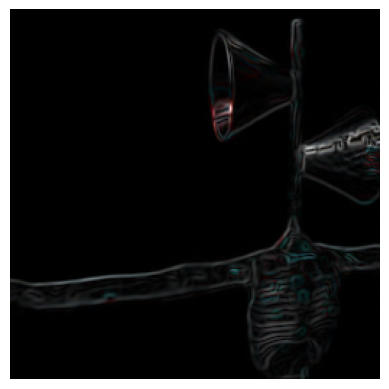

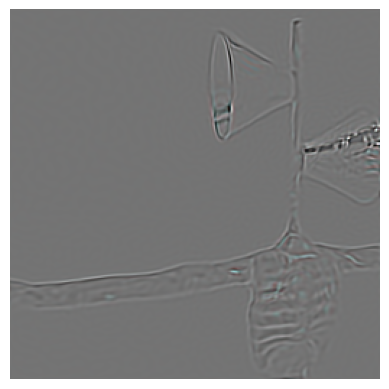

In [47]:
visualize_filter(decoded, gradient_filter)
visualize_filter(decoded, laplace_filter)

The following image was obtained after training with all of the pixels

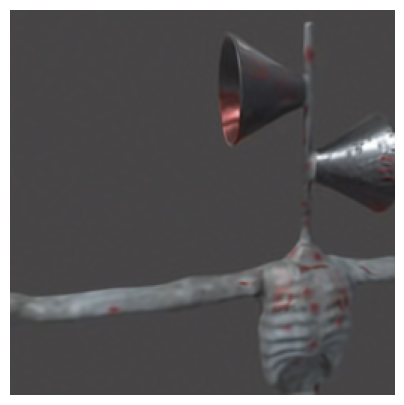

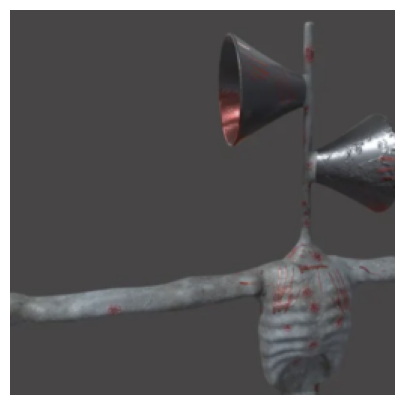

In [48]:
# Top one is from model, bottom is the original image
y_hat = learn.model(x.to(device))
TensorImage(y_hat.transpose(0, 1).reshape(3, 256, 256)).show()
image.show();

In [49]:
# Number of pixels on the image
256*256*3

196608

In [50]:
# Number of parameters on the model
sum([p.numel() for p in learn.model.parameters()])

44099

# Training a Relu model

In [23]:
from typing import List
def relu_model(dimensions: List[int]):
    """
        Sequence of linear layers followed by ReLU
    """
    layers = []
    for dim0, dim1 in zip(dimensions[:-1], dimensions[1:]):
        layers.append(nn.Linear(dim0, dim1))
        layers.append(nn.ReLU())
    return nn.Sequential(*layers)

In [24]:
learn = Learner(dls, 
    relu_model([2, 256, 128, 64, 32, 3]).to(device), 
    loss_func=MSELossFlat(),
    opt_func=ranger
    )

In [25]:
learn.model

Sequential(
  (0): Linear(in_features=2, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=3, bias=True)
  (9): ReLU()
)

In [26]:
learn.fit_flat_cos(5, lr=1e-3)

epoch,train_loss,valid_loss,time
0,0.036766,0.034343,00:01
1,0.034152,0.033971,00:01
2,0.033597,0.033389,00:01
3,0.033023,0.032826,00:01
4,0.032640,0.032554,00:01


This is the prediction of the ReLU model after the same 5 epochs

<Axes: >

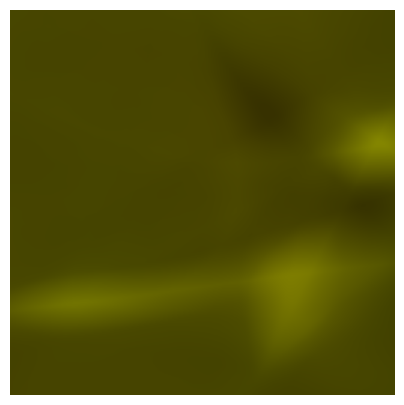

In [27]:
decode_prediction(learn, x).show()

In [28]:
learn.fit_flat_cos(300, lr=1e-3)

epoch,train_loss,valid_loss,time
0,0.032394,0.032183,00:01
1,0.019845,0.003554,00:01
2,0.002522,0.002015,00:01
3,0.001739,0.001675,00:01
4,0.001523,0.001517,00:01
5,0.001401,0.001363,00:01
6,0.001366,0.001252,00:01
7,0.001214,0.001219,00:01
8,0.001205,0.001217,00:01
9,0.001216,0.001244,00:01


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.097965665..1.0221604].


<Axes: title={'center': 'decoded'}>

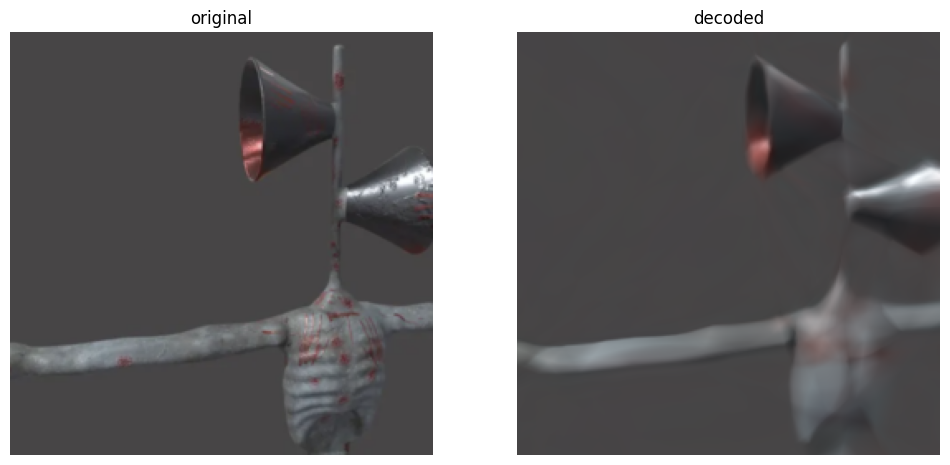

In [29]:
relu_pred = decode_prediction(learn, x)
_, ax = subplots(1, 2, figsize=(12, 20))
image.show(ax[0], title='original')
relu_pred.show(ax[1], title='decoded')

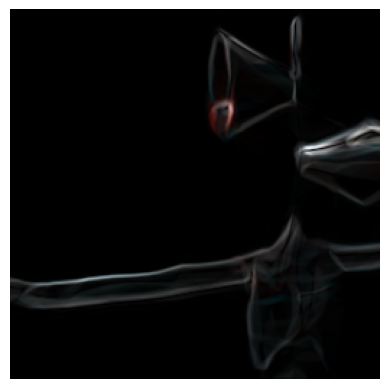

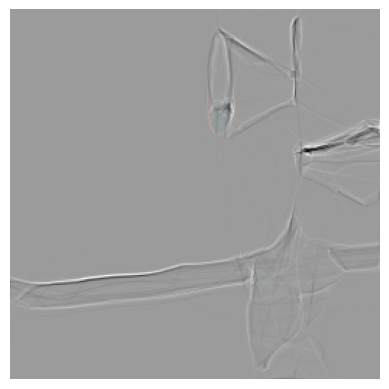

In [30]:
visualize_filter(relu_pred, gradient_filter)
visualize_filter(relu_pred, laplace_filter)